In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

In [37]:
df = pd.read_parquet(
    "../../trained_models/test4/predictions_best_val_loss/ALL_predictions.parquet"
)
df["probabilities"] = df["logits"].apply(lambda x: np.exp(x) / np.sum(np.exp(x)))
df["predicted_label_probability"] = df["probabilities"].apply(lambda x: np.max(x))
df_test = df[df["stage"] == "test"]
LABEL_ENCODING = {
    "healthy": 0,
    "scab": 1,
    "rust": 2,
    "frog_eye_leaf_spot": 3,
    "powdery_mildew": 4,
}

In [38]:
df_test.head()

,id,image_path,label,stage,true_label,predicted_label,logits,embedding,probabilities,predicted_label_probability
12540,plant_pathology_12540,f4e0f3d6cdc21449.jpg,healthy,test,0,0,"[5.9578905, 0.42065713, -5.507152, -1.443414, ...","[0.8678111, 0.11397629, 0.80153644, 1.0588629,...","[0.9952267, 0.0039186105, 1.04404035e-05, 0.00...",0.995227
12541,plant_pathology_12541,ef6d90e1c01ded90.jpg,powdery_mildew,test,4,4,"[-1.5356348, -1.4539038, -3.7593925, -1.628738...","[1.6914755, 0.4146839, 0.0, 2.3988786, 0.19858...","[0.00025650728, 0.0002783524, 2.7754535e-05, 0...",0.999204
12542,plant_pathology_12542,9aac534b4bb624f4.jpg,frog_eye_leaf_spot,test,3,3,"[-11.074297, 2.3991048, 2.7187505, 13.330098, ...","[0.2655799, 1.0805931, 3.70922, 0.09137227, 0....","[2.5193436e-11, 1.7894166e-05, 2.463382e-05, 0...",0.999957
12543,plant_pathology_12543,891b99b0617e6567.jpg,healthy,test,0,0,"[6.1893497, -0.29004213, -5.5005617, -1.336389...","[0.9056382, 0.12818289, 0.7405, 1.2189583, 1.0...","[0.99769557, 0.0015312072, 8.358609e-06, 0.000...",0.997696
12544,plant_pathology_12544,fa8f7558aa489694.jpg,rust,test,2,2,"[-8.103739, -2.636804, 12.877483, 5.4338217, -...","[0.03275104, 2.398438, 0.900273, 0.023848446, ...","[7.72177e-10, 1.8280012e-07, 0.99941504, 0.000...",0.999415


In [28]:
for label in LABEL_ENCODING.keys():
    df_label = df_test[df_test["true_label"] == LABEL_ENCODING[label]]
    correct = len(df_label[df_label["true_label"] == df_label["predicted_label"]])
    total = len(df_label)
    accuracy = correct / total if total > 0 else 0
    print(f"Label: {label}, Accuracy: {accuracy:.2f} ({correct}/{total})")

total_correct = len(df_test[df_test["true_label"] == df_test["predicted_label"]])
total_samples = len(df_test)
overall_accuracy = total_correct / total_samples if total_samples > 0 else 0
print(f"Overall Accuracy: {overall_accuracy:.2f} ({total_correct}/{total_samples})")

Label: healthy, Accuracy: 0.91 (841/925)
Label: scab, Accuracy: 0.66 (641/965)
Label: rust, Accuracy: 0.72 (268/372)
Label: frog_eye_leaf_spot, Accuracy: 1.00 (633/636)
Label: powdery_mildew, Accuracy: 0.91 (216/237)
Overall Accuracy: 0.83 (2599/3135)


In [29]:
print("Classification Report:")
print(classification_report(df_test["true_label"], df_test["predicted_label"], target_names=LABEL_ENCODING.keys()))

Classification Report:
                    precision    recall  f1-score   support

           healthy       0.81      0.91      0.86       925
              scab       0.98      0.66      0.79       965
              rust       0.95      0.72      0.82       372
frog_eye_leaf_spot       0.79      1.00      0.88       636
    powdery_mildew       0.60      0.91      0.72       237

          accuracy                           0.83      3135
         macro avg       0.83      0.84      0.81      3135
      weighted avg       0.86      0.83      0.83      3135



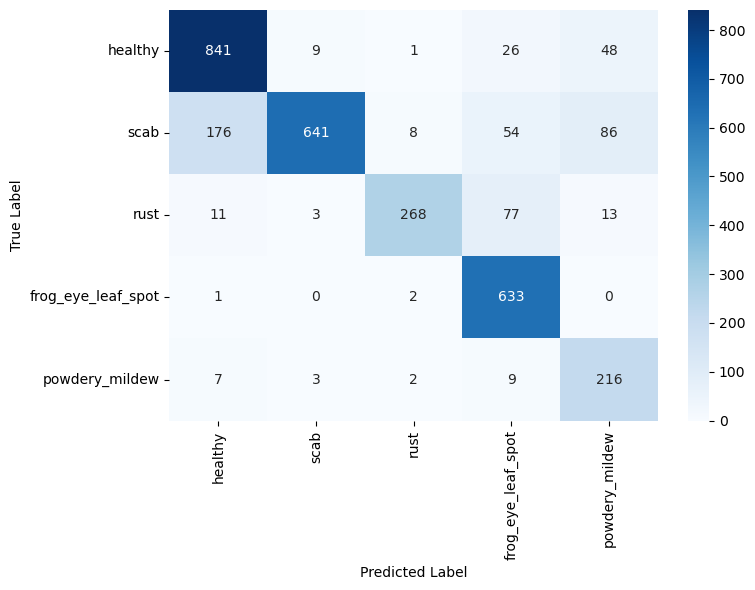

In [36]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    # cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    fmt = "d"
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    df_test["true_label"],
    df_test["predicted_label"],
    class_names=list(LABEL_ENCODING.keys()),
)

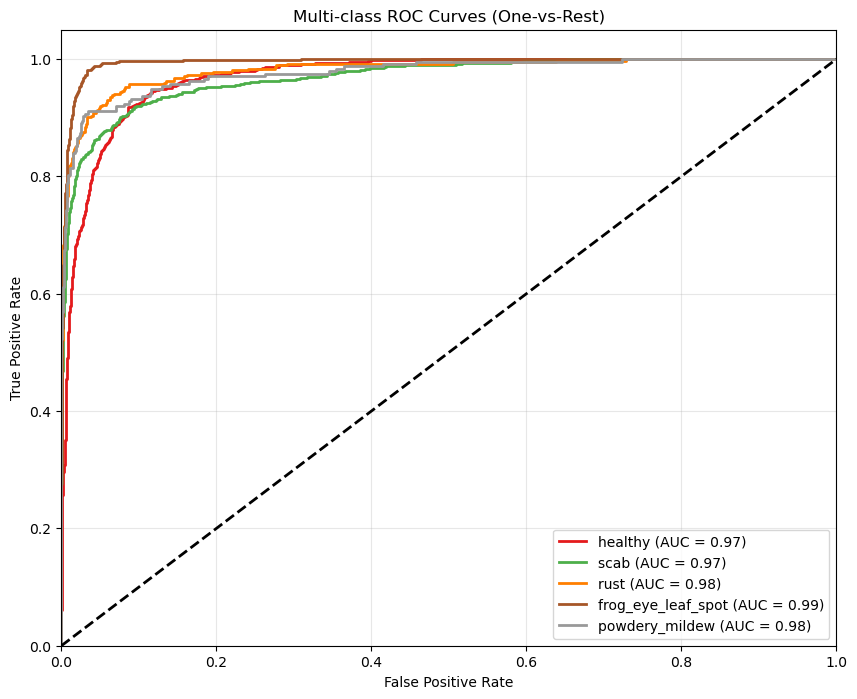

In [44]:
def plot_multiclass_roc_curves(y_true, probabilities, class_names):
    # Binarize the output
    y_test_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probabilities[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})",
        )

    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-class ROC Curves (One-vs-Rest)")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    return roc_auc

roc_auc = plot_multiclass_roc_curves(
    df_test["true_label"],
    np.vstack(df_test["probabilities"].values),
    class_names=list(LABEL_ENCODING.keys()),
)